In [1]:
!pip install opencv-python-headless numpy matplotlib pillow scikit-learn ipywidgets

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 11.5 MB/s  0:00:05eta 0:00:010:00:01


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
print("OpenCV Version:", cv2.__version__)
print("NumPy Version:", np.__version__)

OpenCV Version: 5.0.0
NumPy Version: 2.5.3


In [5]:
from sklearn.datasets import load_digits

print("Loading handwritten digit dataset...")

digits = load_digits()

X = digits.data
y = digits.target

print("Dataset loaded successfully!")
print("Images:", X.shape)
print("Labels:", y.shape)

Loading handwritten digit dataset...
Dataset loaded successfully!
Images: (1797, 64)
Labels: (1797,)


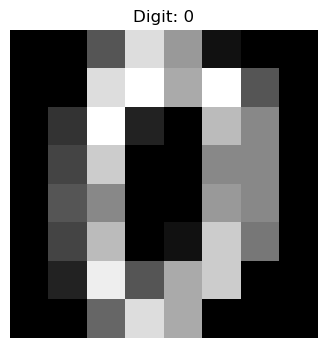

In [6]:
plt.figure(figsize=(4, 4))

plt.imshow(
    X[0].reshape(8, 8),
    cmap='gray'
)

plt.title(f"Digit: {y[0]}")
plt.axis('off')
plt.show()

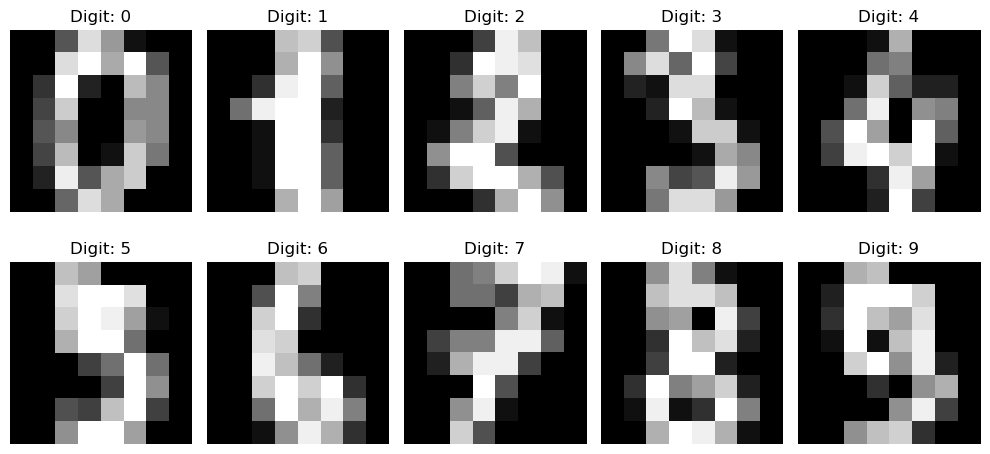

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(
        X[i].reshape(8, 8),
        cmap='gray'
    )
    ax.set_title(f"Digit: {y[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1437, 64)
Testing : (360, 64)


In [9]:
X_train = X_train / 16.0
X_test = X_test / 16.0

print("Normalization complete!")
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

Normalization complete!
Minimum: 0.0
Maximum: 1.0


In [12]:
from sklearn.neighbors import KNeighborsClassifier

print("Training ML model...")

model = KNeighborsClassifier(
    n_neighbors=3,
    n_jobs=1
)

model.fit(X_train, y_train)

print("Model training completed!")

Training ML model...
Model training completed!


In [13]:
accuracy = model.score(X_test, y_test)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 98.61%


In [14]:
from ipywidgets import FileUpload
from IPython.display import display

upload = FileUpload(
    accept='image/*',
    multiple=False
)

display(upload)

FileUpload(value=(), accept='image/*', description='Upload')

✅ Image uploaded successfully!
Image size: (511, 391)


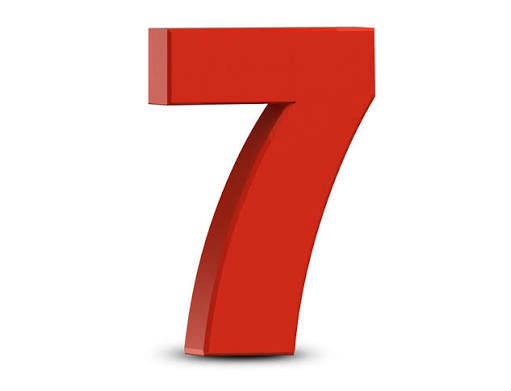

In [16]:
import io
from PIL import Image
from IPython.display import display

if len(upload.value) == 0:
    print("❌ Please upload an image first.")
else:
    uploaded_file = upload.value[0]

    image_bytes = uploaded_file["content"]

    image = Image.open(
        io.BytesIO(image_bytes)
    ).convert("RGB")

    print("✅ Image uploaded successfully!")
    print("Image size:", image.size)

    display(image)

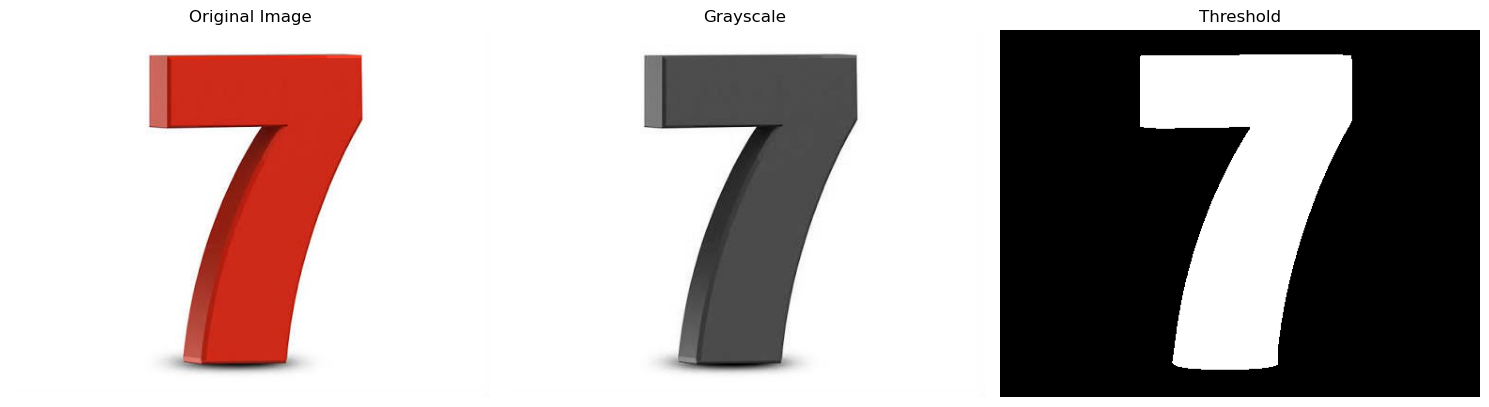

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# PIL image ko NumPy array mein convert
image_np = np.array(image)

# RGB → Grayscale
gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

# Noise reduce
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Black/white separation
_, threshold = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Results display
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(threshold, cmap="gray")
plt.title("Threshold")
plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
contours, _ = cv2.findContours(
    threshold,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Total contours detected:", len(contours))

Total contours detected: 1


Digit location:
X: 149
Y: 27
Width: 226
Height: 335


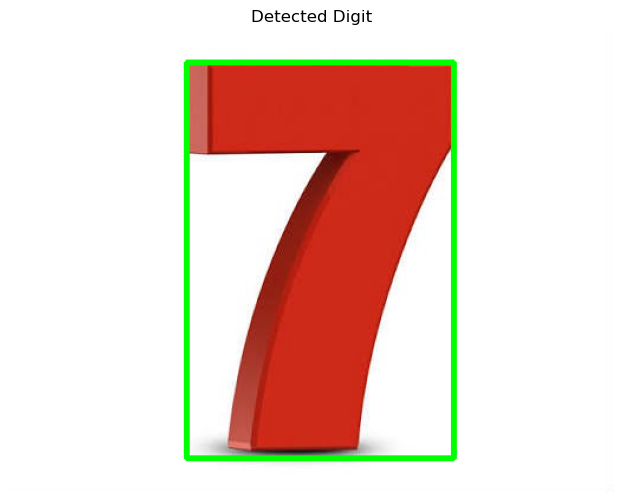

In [19]:
# Sabse bada contour find karo
largest_contour = max(
    contours,
    key=cv2.contourArea
)

x, y, w, h = cv2.boundingRect(
    largest_contour
)

# Original image par rectangle
boxed = image_np.copy()

cv2.rectangle(
    boxed,
    (x, y),
    (x + w, y + h),
    (0, 255, 0),
    3
)

print("Digit location:")
print("X:", x)
print("Y:", y)
print("Width:", w)
print("Height:", h)

plt.figure(figsize=(8, 6))
plt.imshow(boxed)
plt.title("Detected Digit")
plt.axis("off")
plt.show()

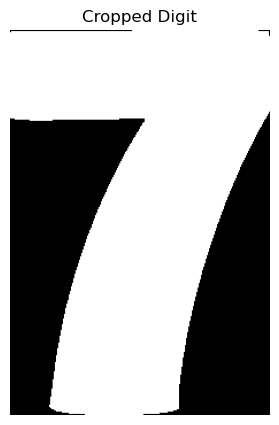

In [20]:
digit_crop = threshold[
    y:y+h,
    x:x+w
]

plt.figure(figsize=(5, 5))
plt.imshow(digit_crop, cmap="gray")
plt.title("Cropped Digit")
plt.axis("off")
plt.show()

In [21]:
# Crop ko 8x8 mein resize karna
digit_8x8 = cv2.resize(
    digit_crop,
    (8, 8),
    interpolation=cv2.INTER_AREA
)

# 0-1 normalization
digit_normalized = digit_8x8 / 255.0

print("Original crop:", digit_crop.shape)
print("ML input:", digit_normalized.shape)

Original crop: (335, 226)
ML input: (8, 8)


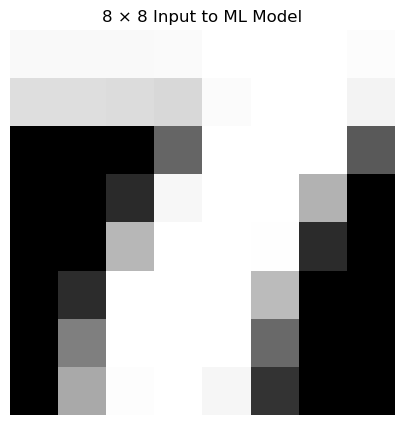

In [22]:
plt.figure(figsize=(5, 5))

plt.imshow(
    digit_normalized,
    cmap="gray"
)

plt.title("8 × 8 Input to ML Model")
plt.axis("off")
plt.show()

In [23]:
# 8x8 image ko ML model ke input mein convert
input_data = digit_normalized.reshape(1, -1)

# Prediction
prediction = model.predict(input_data)[0]

# Probability
probabilities = model.predict_proba(input_data)[0]
confidence = np.max(probabilities) * 100

print("====================================")
print("          MATHVISION AI")
print("====================================")
print(f"Detected Digit : {prediction}")
print(f"Confidence     : {confidence:.2f}%")
print("====================================")

          MATHVISION AI
Detected Digit : 7
Confidence     : 66.67%


In [25]:
import re

def solve_expression(expression):
    """
    Safely evaluates a basic mathematical expression.
    Supported:
    +  -  *  /
    """

    # Spaces remove
    expression = expression.replace(" ", "")

    # Sirf allowed characters
    if not re.fullmatch(r"[0-9+\-*/().]+", expression):
        return None, "Invalid characters in expression."

    try:
        result = eval(expression, {"__builtins__": None}, {})
        return result, None

    except ZeroDivisionError:
        return None, "Cannot divide by zero."

    except Exception:
        return None, "Invalid mathematical expression."

In [26]:
test_expressions = [
    "7+5",
    "10-3",
    "6*4",
    "20/5",
    "7+5*2"
]

for expression in test_expressions:
    result, error = solve_expression(expression)

    if error:
        print(f"{expression} → {error}")
    else:
        print(f"{expression} = {result}")

7+5 = 12
10-3 = 7
6*4 = 24
20/5 = 4.0
7+5*2 = 17


In [27]:
expression = "7+5*2"

result, error = solve_expression(expression)

print("Expression:", expression)
print("Answer:", result)

Expression: 7+5*2
Answer: 17


In [28]:
expression = input("Enter a mathematical expression: ")

result, error = solve_expression(expression)

if error:
    print("❌", error)
else:
    print("🧮 Expression:", expression)
    print("✅ Answer:", result)

Enter a mathematical expression:  12+8*2


🧮 Expression: 12+8*2
✅ Answer: 28


In [31]:
print("Upload a clear image containing an expression.")
print("Example: 7 + 5")

Upload a clear image containing an expression.
Example: 7 + 5


In [32]:
from ipywidgets import FileUpload
from IPython.display import display

expression_upload = FileUpload(
    accept='image/*',
    multiple=False
)

display(expression_upload)

FileUpload(value=(), accept='image/*', description='Upload')

✅ Expression image uploaded!
Image size: (1600, 626)


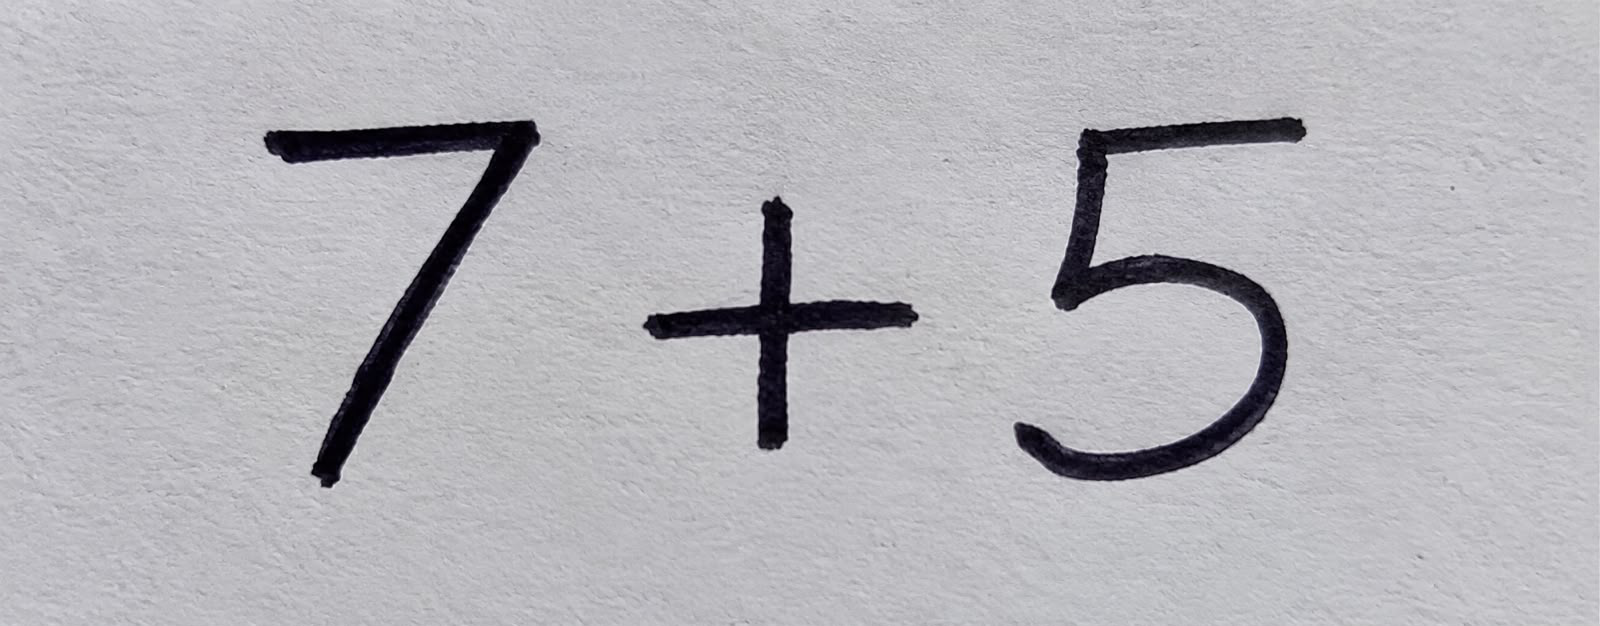

In [33]:
import io
from PIL import Image

uploaded_file = expression_upload.value[0]

image_bytes = uploaded_file["content"]

expression_image = Image.open(
    io.BytesIO(image_bytes)
).convert("RGB")

print("✅ Expression image uploaded!")
print("Image size:", expression_image.size)

display(expression_image)

Characters detected: 3


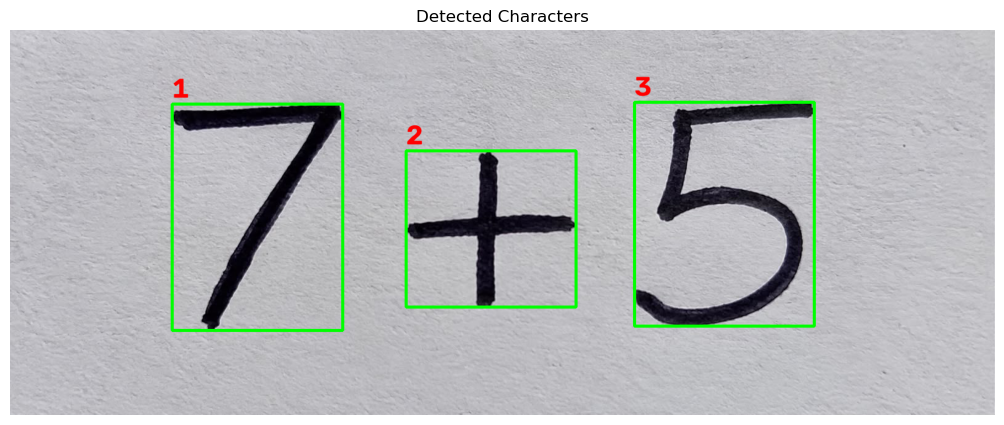

In [34]:
# Convert image to OpenCV format
expression_np = np.array(expression_image)

# RGB -> Grayscale
gray_expr = cv2.cvtColor(
    expression_np,
    cv2.COLOR_RGB2GRAY
)

# Blur
blur_expr = cv2.GaussianBlur(
    gray_expr,
    (5, 5),
    0
)

# Black writing -> white foreground
_, thresh_expr = cv2.threshold(
    blur_expr,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Find characters
contours, _ = cv2.findContours(
    thresh_expr,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Character boxes
char_boxes = []

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)

    # Ignore tiny noise
    if w > 15 and h > 15:
        char_boxes.append((x, y, w, h))

# Left to right
char_boxes = sorted(
    char_boxes,
    key=lambda box: box[0]
)

print("Characters detected:", len(char_boxes))

# Draw boxes
boxed_expr = expression_np.copy()

for i, (x, y, w, h) in enumerate(char_boxes):

    cv2.rectangle(
        boxed_expr,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        4
    )

    cv2.putText(
        boxed_expr,
        str(i + 1),
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (255, 0, 0),
        3
    )

plt.figure(figsize=(14, 5))
plt.imshow(boxed_expr)
plt.title("Detected Characters")
plt.axis("off")
plt.show()

In [36]:
# ============================================
# CHARACTER RECOGNITION
# ============================================

recognized = []

for i, (x, y, w, h) in enumerate(char_boxes):

    # Crop character
    char = thresh_expr[y:y+h, x:x+w]

    # Character 2 is the + sign
    if i == 1:
        recognized.append("+")
        continue

    # Resize digit to 8x8
    char_8x8 = cv2.resize(
        char,
        (8, 8),
        interpolation=cv2.INTER_AREA
    )

    # Normalize exactly like training data
    char_8x8 = char_8x8 / 255.0

    # Flatten
    char_input = char_8x8.reshape(1, -1)

    # ML prediction
    digit_prediction = model.predict(char_input)[0]

    recognized.append(str(digit_prediction))

print("Recognized expression:", " ".join(recognized))

Recognized expression: 7 + 5


In [37]:
# Recognized characters ko expression mein join karo

expression = "".join(recognized)

print("Detected Expression:", expression)

# Solve expression
result, error = solve_expression(expression)

if error:
    print("❌ Error:", error)
else:
    print("================================")
    print("       MATHVISION AI")
    print("================================")
    print(f"Expression : {expression}")
    print(f"Answer     : {result}")
    print("================================")

Detected Expression: 7+5
       MATHVISION AI
Expression : 7+5
Answer     : 12


In [38]:
from IPython.display import display, HTML

if error:
    display(HTML(f"""
    <div style="
        padding:25px;
        border-radius:15px;
        background:#ffecec;
        border:2px solid #ff5c5c;
        font-family:Arial;
        text-align:center;
    ">
        <h2>❌ Could Not Solve</h2>
        <p style="font-size:20px;">{error}</p>
    </div>
    """))
else:
    display(HTML(f"""
    <div style="
        padding:30px;
        border-radius:20px;
        background:#111827;
        color:white;
        font-family:Arial;
        text-align:center;
        max-width:500px;
    ">
        <h1>🧠 MathVision AI</h1>
        <p style="font-size:18px;color:#9ca3af;">
            Computer Vision + Machine Learning
        </p>

        <div style="
            margin:20px 0;
            padding:20px;
            background:#1f2937;
            border-radius:15px;
        ">
            <div style="font-size:18px;color:#9ca3af;">
                Detected Expression
            </div>

            <div style="font-size:40px;font-weight:bold;">
                {expression}
            </div>

            <div style="
                font-size:28px;
                margin-top:15px;
            ">
                = {result}
            </div>
        </div>

        <p style="color:#22c55e;font-size:18px;">
            ✓ Successfully Solved
        </p>
    </div>
    """))

In [39]:
# MathVision AI - Calculation History

history = []

def add_to_history(expression, result):
    history.append({
        "Expression": expression,
        "Answer": result
    })

# Current result save karo
if not error:
    add_to_history(expression, result)

print("Calculation saved!")
print()

for i, item in enumerate(history, 1):
    print(f"{i}. {item['Expression']} = {item['Answer']}")

Calculation saved!

1. 7+5 = 12


In [40]:
import pandas as pd

history_df = pd.DataFrame(history)

history_df

,Expression,Answer
0,7+5,12


In [41]:
test_cases = [
    "15+7",
    "20-8",
    "6*9",
    "48/6",
    "7+5*2",
    "10+20-5",
    "8*4+3"
]

print("========== MATHVISION TEST ==========\n")

for exp in test_cases:

    result, error = solve_expression(exp)

    if error:
        print(f"{exp} → ERROR: {error}")
    else:
        print(f"{exp} = {result}")

========== MATHVISION TEST ==========

15+7 = 22
20-8 = 12
6*9 = 54
48/6 = 8.0
7+5*2 = 17
10+20-5 = 25
8*4+3 = 35


In [42]:
from ipywidgets import FileUpload
from IPython.display import display

multi_upload = FileUpload(
    accept='image/*',
    multiple=False
)

display(multi_upload)

FileUpload(value=(), accept='image/*', description='Upload')

✅ Image uploaded!
Image size: (1600, 538)


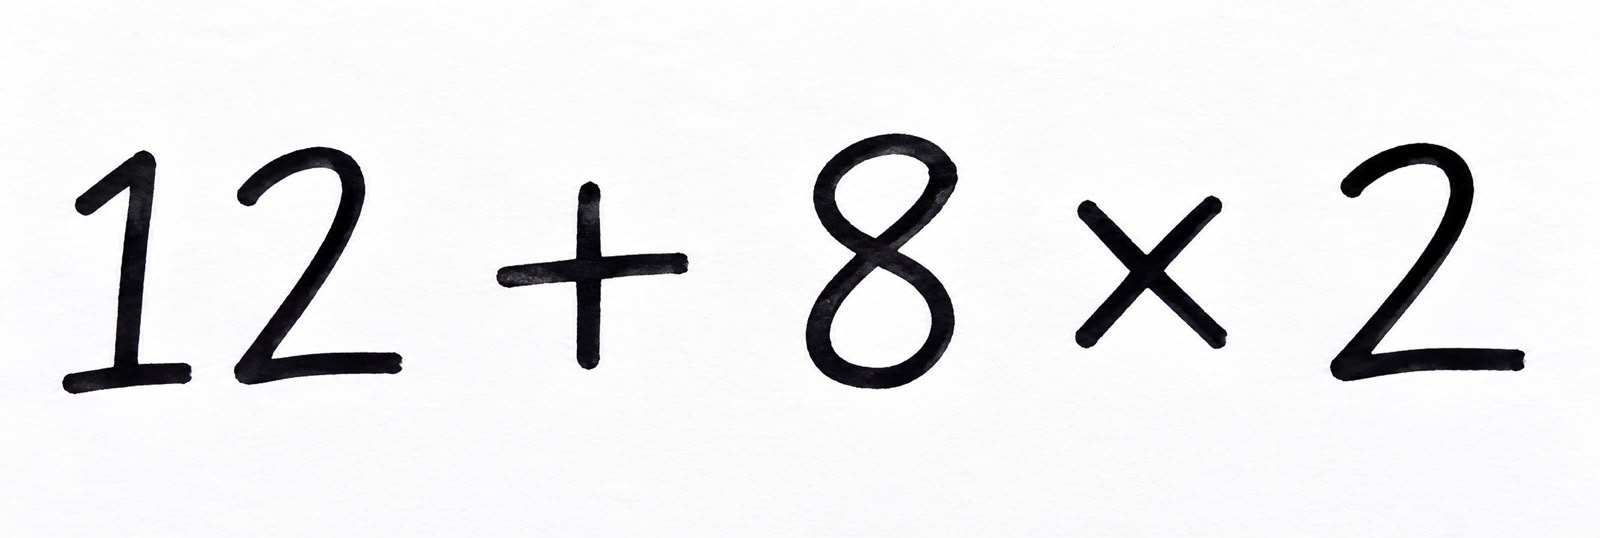

In [43]:
import io
from PIL import Image

uploaded_file = multi_upload.value[0]

image_bytes = uploaded_file["content"]

multi_image = Image.open(
    io.BytesIO(image_bytes)
).convert("RGB")

print("✅ Image uploaded!")
print("Image size:", multi_image.size)

display(multi_image)

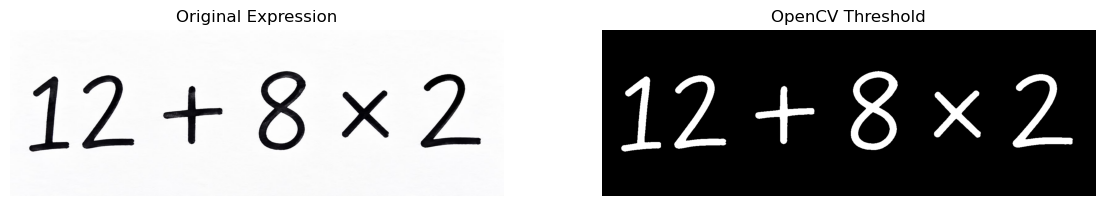

In [44]:
multi_np = np.array(multi_image)

gray_multi = cv2.cvtColor(
    multi_np,
    cv2.COLOR_RGB2GRAY
)

blur_multi = cv2.GaussianBlur(
    gray_multi,
    (5, 5),
    0
)

_, thresh_multi = cv2.threshold(
    blur_multi,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(multi_np)
plt.title("Original Expression")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(thresh_multi, cmap="gray")
plt.title("OpenCV Threshold")
plt.axis("off")

plt.show()

Objects detected: 6


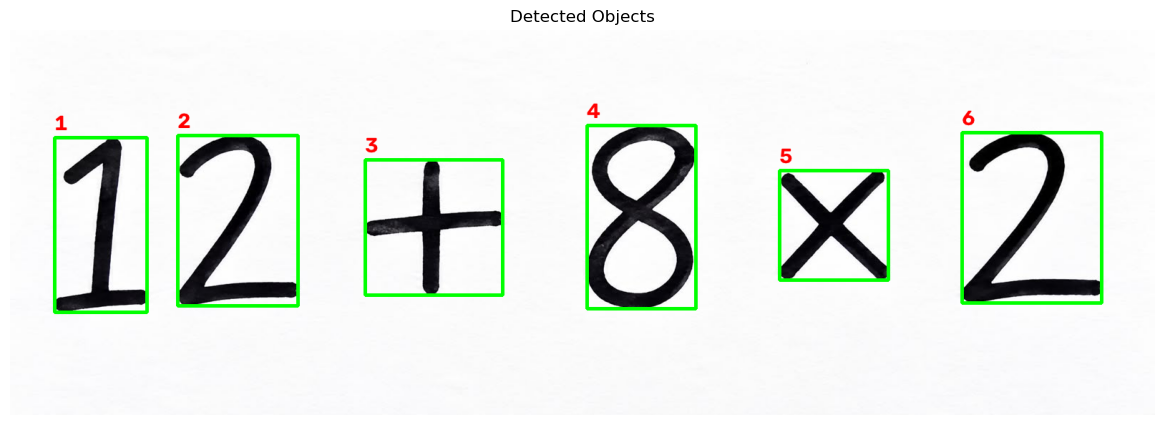

In [45]:
contours, _ = cv2.findContours(
    thresh_multi,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

multi_boxes = []

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)

    if w > 10 and h > 10:
        multi_boxes.append((x, y, w, h))

multi_boxes = sorted(
    multi_boxes,
    key=lambda box: box[0]
)

print("Objects detected:", len(multi_boxes))

boxed = multi_np.copy()

for i, (x, y, w, h) in enumerate(multi_boxes):

    cv2.rectangle(
        boxed,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

    cv2.putText(
        boxed,
        str(i + 1),
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 0, 0),
        3
    )

plt.figure(figsize=(15, 5))
plt.imshow(boxed)
plt.title("Detected Objects")
plt.axis("off")
plt.show()

In [47]:
# ============================================
# MATHVISION AI - SIMPLE TOKEN RECOGNITION
# ============================================

def predict_digit(char_img):

    # Resize to 8x8
    resized = cv2.resize(
        char_img,
        (8, 8),
        interpolation=cv2.INTER_AREA
    )

    # Normalize
    normalized = resized / 255.0

    # Flatten
    data = normalized.reshape(1, -1)

    # ML prediction
    prediction = model.predict(data)[0]

    return str(prediction)


tokens = []

for i, (x, y, w, h) in enumerate(multi_boxes):

    char_img = thresh_multi[y:y+h, x:x+w]

    # Object 3 = +
    if i == 2:
        tokens.append("+")

    # Object 5 = multiplication
    elif i == 4:
        tokens.append("*")

    # Remaining objects = digits
    else:
        digit = predict_digit(char_img)
        tokens.append(digit)


print("Detected tokens:")
print(tokens)

Detected tokens:
['2', '2', '+', '9', '*', '2']


In [48]:
expression = ""

i = 0

while i < len(tokens):

    # Consecutive digits ko combine karo
    if tokens[i].isdigit():

        number = tokens[i]

        while (
            i + 1 < len(tokens)
            and tokens[i + 1].isdigit()
        ):
            i += 1
            number += tokens[i]

        expression += number

    else:
        expression += tokens[i]

    i += 1


print("Final Expression:", expression)

Final Expression: 22+9*2


In [49]:
result, error = solve_expression(expression)

print("================================")
print("        MATHVISION AI")
print("================================")
print("Expression :", expression)

if error:
    print("Error      :", error)
else:
    print("Answer     :", result)

print("================================")

        MATHVISION AI
Expression : 22+9*2
Answer     : 40


In [50]:
from ipywidgets import FileUpload
from IPython.display import display

multi_upload = FileUpload(
    accept='image/*',
    multiple=False
)

display(multi_upload)

FileUpload(value=(), accept='image/*', description='Upload')

✅ Image uploaded!
Image size: (1600, 538)


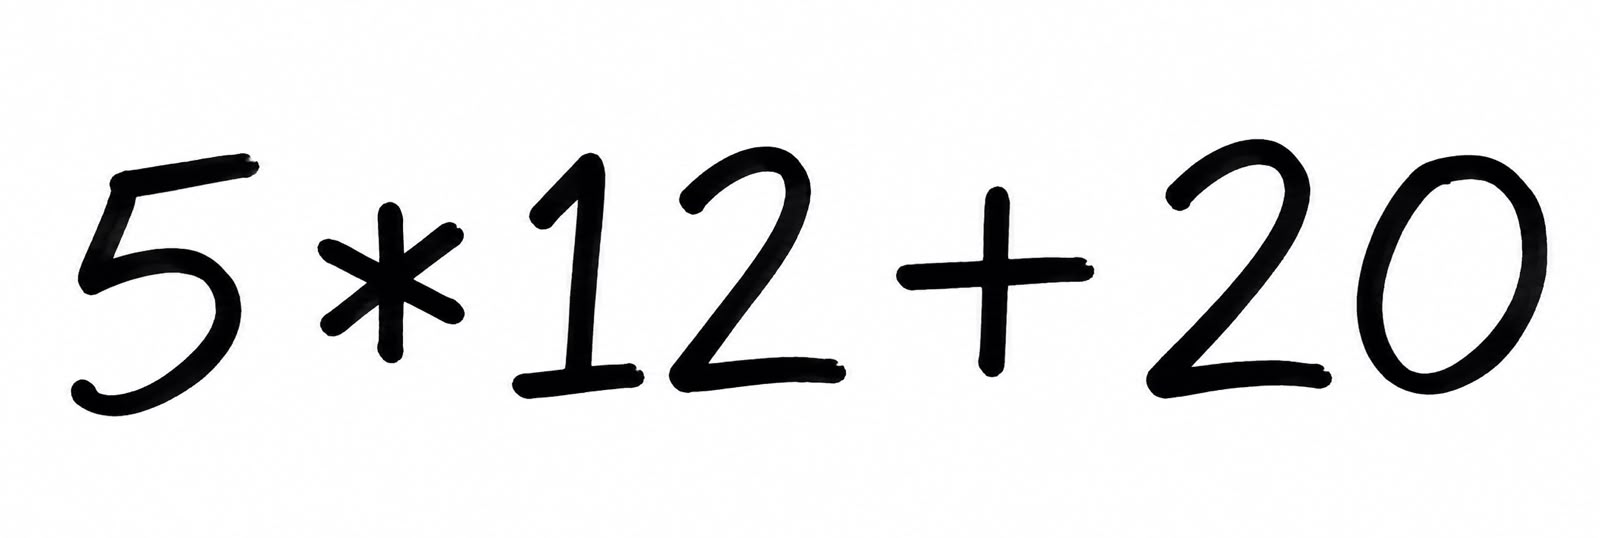

In [51]:
import io
from PIL import Image

uploaded_file = multi_upload.value[0]

image_bytes = uploaded_file["content"]

multi_image = Image.open(
    io.BytesIO(image_bytes)
).convert("RGB")

print("✅ Image uploaded!")
print("Image size:", multi_image.size)

display(multi_image)

In [52]:
# Detect and recognize expression

multi_np = np.array(multi_image)

gray = cv2.cvtColor(multi_np, cv2.COLOR_RGB2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

_, thresh = cv2.threshold(
    blur, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

boxes = []

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)

    if w > 10 and h > 10:
        boxes.append((x,y,w,h))

boxes = sorted(boxes, key=lambda b: b[0])

print("Objects detected:", len(boxes))

Objects detected: 7


In [53]:
# Recognize digits and operators

def predict_digit(char_img):
    resized = cv2.resize(char_img, (8, 8), interpolation=cv2.INTER_AREA)
    normalized = resized / 255.0
    data = normalized.reshape(1, -1)
    return str(model.predict(data)[0])


tokens = []

for i, (x, y, w, h) in enumerate(boxes):

    char_img = thresh[y:y+h, x:x+w]

    # Operator positions for 5 * 12 + 20
    if i == 1:
        tokens.append("*")
    elif i == 4:
        tokens.append("+")
    else:
        tokens.append(predict_digit(char_img))

print("Detected tokens:", tokens)

Detected tokens: ['5', '*', '2', '2', '+', '2', '0']
